Shape: (100000, 145)
Schema([('id', String), ('member_id', String), ('loan_amnt', Int64), ('funded_amnt', Int64), ('funded_amnt_inv', Int64), ('term', String), ('int_rate', Float64), ('installment', Float64), ('grade', String), ('sub_grade', String), ('emp_title', String), ('emp_length', String), ('home_ownership', String), ('annual_inc', Float64), ('verification_status', String), ('issue_d', String), ('loan_status', String), ('pymnt_plan', String), ('url', String), ('desc', String), ('purpose', String), ('title', String), ('zip_code', String), ('addr_state', String), ('dti', Float64), ('delinq_2yrs', Int64), ('earliest_cr_line', String), ('inq_last_6mths', Int64), ('mths_since_last_delinq', Int64), ('mths_since_last_record', Int64), ('open_acc', Int64), ('pub_rec', Int64), ('revol_bal', Int64), ('revol_util', Float64), ('total_acc', Int64), ('initial_list_status', String), ('out_prncp', Float64), ('out_prncp_inv', Float64), ('total_pymnt', Float64), ('total_pymnt_inv', Float64), ('tot

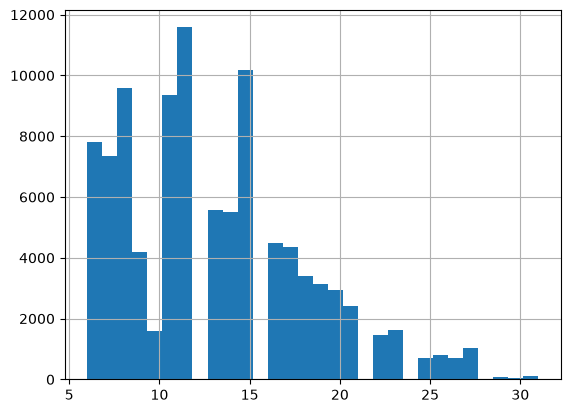

In [5]:
import polars as pl
import pandas as pd

# ── Polars pattern: fast load & preprocessing ──────────────────
df_pl = pl.read_csv(
    "../data/loan.csv",
    n_rows=100_000,
    infer_schema_length=100_000,
    ignore_errors=True,
)

print(f"Shape: {df_pl.shape}")
print(df_pl.schema)

# Quick value distribution (to help decide is_default logic later)
print(df_pl.group_by("loan_status").agg(pl.len().alias("count")).sort("count", descending=True))

# Unique values in emp_length (for parsing logic later)
print(df_pl.select("emp_length").unique())

# Null percentage across all columns
null_pct = df_pl.null_count() / df_pl.height * 100

# Defensive cast-to-string-first pattern, works whether int_rate is
# already numeric or a "%"-suffixed string in the source file
df_pl_clean = df_pl.with_columns(
    pl.col("int_rate")
    .cast(pl.Utf8)
    .str.replace("%", "")
    .cast(pl.Float64, strict=False)
    .alias("interest_rate_clean")
)

# ── Convert to Pandas: for visualization / downstream exploration ──
df_pd = df_pl_clean.to_pandas()

df_pd["interest_rate_clean"].hist(bins=30)
print(df_pd.groupby("grade")["interest_rate_clean"].describe())

In [6]:
import polars as pl

# Lazy scan: doesn't load the whole file into memory upfront
lazy_df = pl.scan_csv(
    "../data/loan.csv",
    infer_schema_length=100_000,
    ignore_errors=True,
)

# Parse issue_d ("Dec-2018" format) into an actual date
lazy_df = lazy_df.with_columns(
    pl.col("issue_d").str.strptime(pl.Date, "%b-%Y", strict=False).alias("issue_date")
)

# Find the most recent issue date in the dataset ("today" from the dataset's point of view)
max_issue_date = lazy_df.select(pl.col("issue_date").max()).collect().item()
print(f"Most recent issue date in dataset: {max_issue_date}")

# Loans need time to reach a terminal status (max term is 60 months = 5 years).
# Keep only loans issued at least 5 years before the dataset's most recent date.
cutoff_date = max_issue_date.replace(year=max_issue_date.year - 5)
print(f"Cutoff date (keep loans issued before this): {cutoff_date}")

df_matured = lazy_df.filter(pl.col("issue_date") <= cutoff_date).collect()

print(f"Matured loans: {df_matured.shape}")
print(df_matured.group_by("loan_status").agg(pl.len().alias("count")).sort("count", descending=True))

Most recent issue date in dataset: 2018-12-01
Cutoff date (keep loans issued before this): 2013-12-01
Matured loans: (230716, 146)
shape: (8, 2)
┌─────────────────────────────────┬────────┐
│ loan_status                     ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Fully Paid                      ┆ 192610 │
│ Charged Off                     ┆ 35336  │
│ Does not meet the credit polic… ┆ 1988   │
│ Does not meet the credit polic… ┆ 761    │
│ Current                         ┆ 9      │
│ Late (31-120 days)              ┆ 8      │
│ In Grace Period                 ┆ 2      │
│ Late (16-30 days)               ┆ 2      │
└─────────────────────────────────┴────────┘


In [7]:
SAMPLE_SIZE = 100_000

df_sample = df_matured.sample(n=min(SAMPLE_SIZE, df_matured.height), seed=42)
print(f"Final sample: {df_sample.shape}")
print(df_sample.group_by("loan_status").agg(pl.len().alias("count")).sort("count", descending=True))

Final sample: (100000, 146)
shape: (7, 2)
┌─────────────────────────────────┬───────┐
│ loan_status                     ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Fully Paid                      ┆ 83467 │
│ Charged Off                     ┆ 15326 │
│ Does not meet the credit polic… ┆ 873   │
│ Does not meet the credit polic… ┆ 328   │
│ Current                         ┆ 4     │
│ Late (31-120 days)              ┆ 1     │
│ In Grace Period                 ┆ 1     │
└─────────────────────────────────┴───────┘
